# Import Module

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import QuantileTransformer
from sklearn.metrics import f1_score, classification_report, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_sample_weight
from imblearn.over_sampling import SMOTE

# Load Dataset

In [2]:
# Load Dataset
df_raw  = pd.read_csv('DatasetPerformaSiswa.csv')
df      = df_raw.copy()

df.head()

print(f"Shape awal: {df.shape}")
print(f"Jumlah baris: {df.shape[0]}, Jumlah kolom: {df.shape[1]}")
print()
print("5 baris pertama:")
print(df.head())
print()
print("Tipe data per kolom:")
print(df.dtypes)

Shape awal: (6607, 20)
Jumlah baris: 6607, Jumlah kolom: 20

5 baris pertama:
   Hours_Studied  Attendance Parental_Involvement Access_to_Resources  \
0             23          84                  Low                High   
1             19          64                  Low              Medium   
2             24          98               Medium              Medium   
3             29          89                  Low              Medium   
4             19          92               Medium              Medium   

  Extracurricular_Activities  Sleep_Hours  Previous_Scores Motivation_Level  \
0                         No            7               73              Low   
1                         No            8               59              Low   
2                        Yes            7               91           Medium   
3                        Yes            8               98           Medium   
4                        Yes            6               65           Medium   

  Intern

# Penanganan Missing Values

In [3]:
# Identifikasi Missing Values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]

# Print Hasil
print("Kolom dengan missing values:")
print(missing_df)
print()


Kolom dengan missing values:
                          Missing Count  Missing %
Teacher_Quality                      78       1.18
Parental_Education_Level             90       1.36
Distance_from_Home                   67       1.01



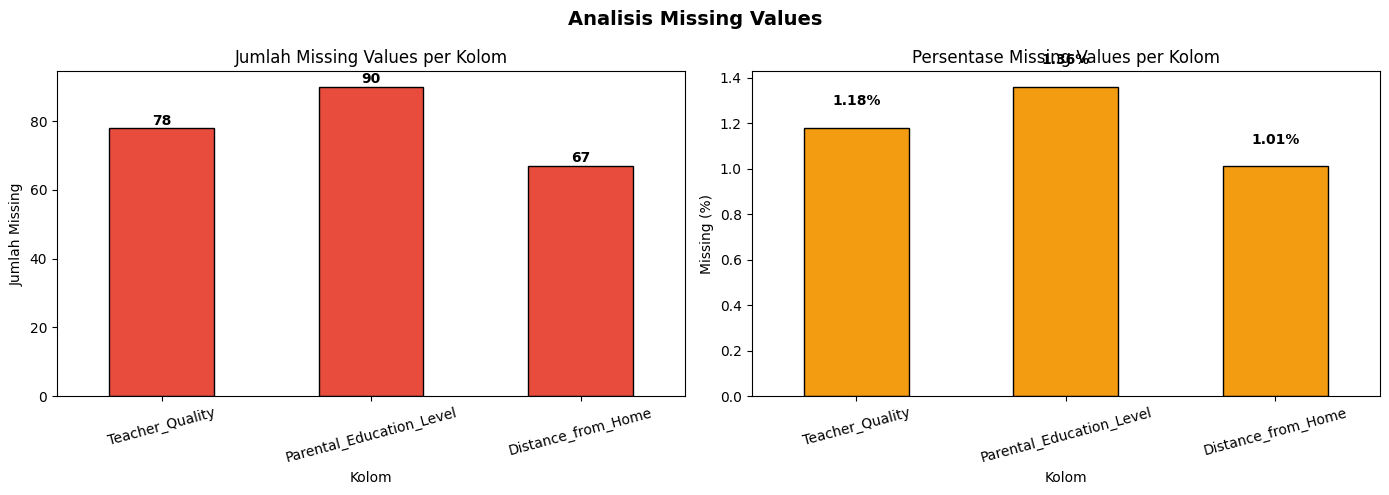

In [20]:
# Visualisasi Missing Values
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Analisis Missing Values', fontsize=14, fontweight='bold')

# Bar chart missing values
missing_df['Missing Count'].plot(kind='bar', ax=axes[0], color='#E74C3C', edgecolor='black')
axes[0].set_title('Jumlah Missing Values per Kolom')
axes[0].set_xlabel('Kolom')
axes[0].set_ylabel('Jumlah Missing')
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(missing_df['Missing Count']):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')

# Missing percentage
missing_df['Missing %'].plot(kind='bar', ax=axes[1], color='#F39C12', edgecolor='black')
axes[1].set_title('Persentase Missing Values per Kolom')
axes[1].set_xlabel('Kolom')
axes[1].set_ylabel('Missing (%)')
axes[1].tick_params(axis='x', rotation=15)
for i, v in enumerate(missing_df['Missing %']):
    axes[1].text(i, v + 0.1, f'{v}%', ha='center', fontweight='bold')

plt.tight_layout()

In [5]:
# Imputasi dengan nilai modus karena semua kolom merupakan categorical
cols_with_missing = missing_df.index.tolist()
for col in cols_with_missing:
    modus = df[col].mode()[0]
    df[col] = df[col].fillna(modus)
    print(f"  Kolom '{col}' -> diisi dengan modus: '{modus}'")

print(f"\nMissing values setelah imputasi: {df.isnull().sum().sum()}")

  Kolom 'Teacher_Quality' -> diisi dengan modus: 'Medium'
  Kolom 'Parental_Education_Level' -> diisi dengan modus: 'High School'
  Kolom 'Distance_from_Home' -> diisi dengan modus: 'Near'

Missing values setelah imputasi: 0


# Pemeriksaan dan Penanganan Duplicate Data

In [6]:
n_dup = df.duplicated().sum()
print(f"Jumlah baris duplikat: {n_dup}")
if n_dup == 0:
    print("Tidak ada duplikat. Data bersih.")
else:
    df.drop_duplicates(inplace=True)
    print(f"Duplikat dihapus. Shape baru: {df.shape}")

Jumlah baris duplikat: 0
Tidak ada duplikat. Data bersih.


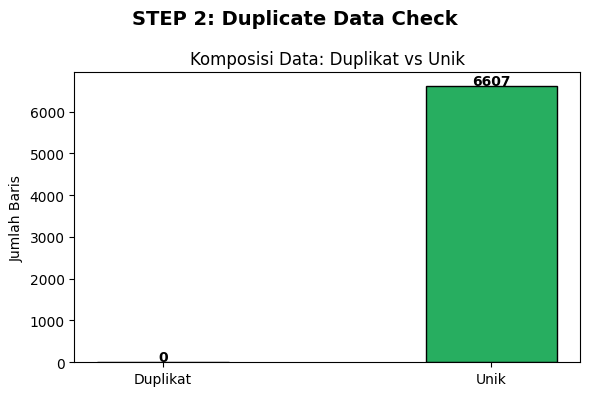

In [9]:
# Visualisasi
fig, ax = plt.subplots(figsize=(6, 4))
fig.suptitle('STEP 2: Duplicate Data Check', fontsize=14, fontweight='bold')
bars = ax.bar(['Duplikat', 'Unik'], [n_dup, len(df) - n_dup],
              color=['#E74C3C', '#27AE60'], edgecolor='black', width=0.4)
ax.set_title('Komposisi Data: Duplikat vs Unik')
ax.set_ylabel('Jumlah Baris')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            str(int(bar.get_height())), ha='center', fontweight='bold')
plt.tight_layout()

# Pemeriksaan Tipe Data dan Konsistensi Nilai Kategorikal

In [7]:
cat_cols = ['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities',
            'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality',
            'School_Type', 'Peer_Influence', 'Learning_Disabilities',
            'Parental_Education_Level', 'Distance_from_Home', 'Gender']
 
for col in cat_cols:
    vals = df[col].unique()
    print(f"  {col}: {vals}")

print("\nSemua nilai kategorikal valid, tidak ada typo atau inkonsistensi.")

  Parental_Involvement: <StringArray>
['Low', 'Medium', 'High']
Length: 3, dtype: str
  Access_to_Resources: <StringArray>
['High', 'Medium', 'Low']
Length: 3, dtype: str
  Extracurricular_Activities: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
  Motivation_Level: <StringArray>
['Low', 'Medium', 'High']
Length: 3, dtype: str
  Internet_Access: <StringArray>
['Yes', 'No']
Length: 2, dtype: str
  Family_Income: <StringArray>
['Low', 'Medium', 'High']
Length: 3, dtype: str
  Teacher_Quality: <StringArray>
['Medium', 'High', 'Low']
Length: 3, dtype: str
  School_Type: <StringArray>
['Public', 'Private']
Length: 2, dtype: str
  Peer_Influence: <StringArray>
['Positive', 'Negative', 'Neutral']
Length: 3, dtype: str
  Learning_Disabilities: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
  Parental_Education_Level: <StringArray>
['High School', 'College', 'Postgraduate']
Length: 3, dtype: str
  Distance_from_Home: <StringArray>
['Near', 'Moderate', 'Far']
Length: 3, dtype: str
  Gende

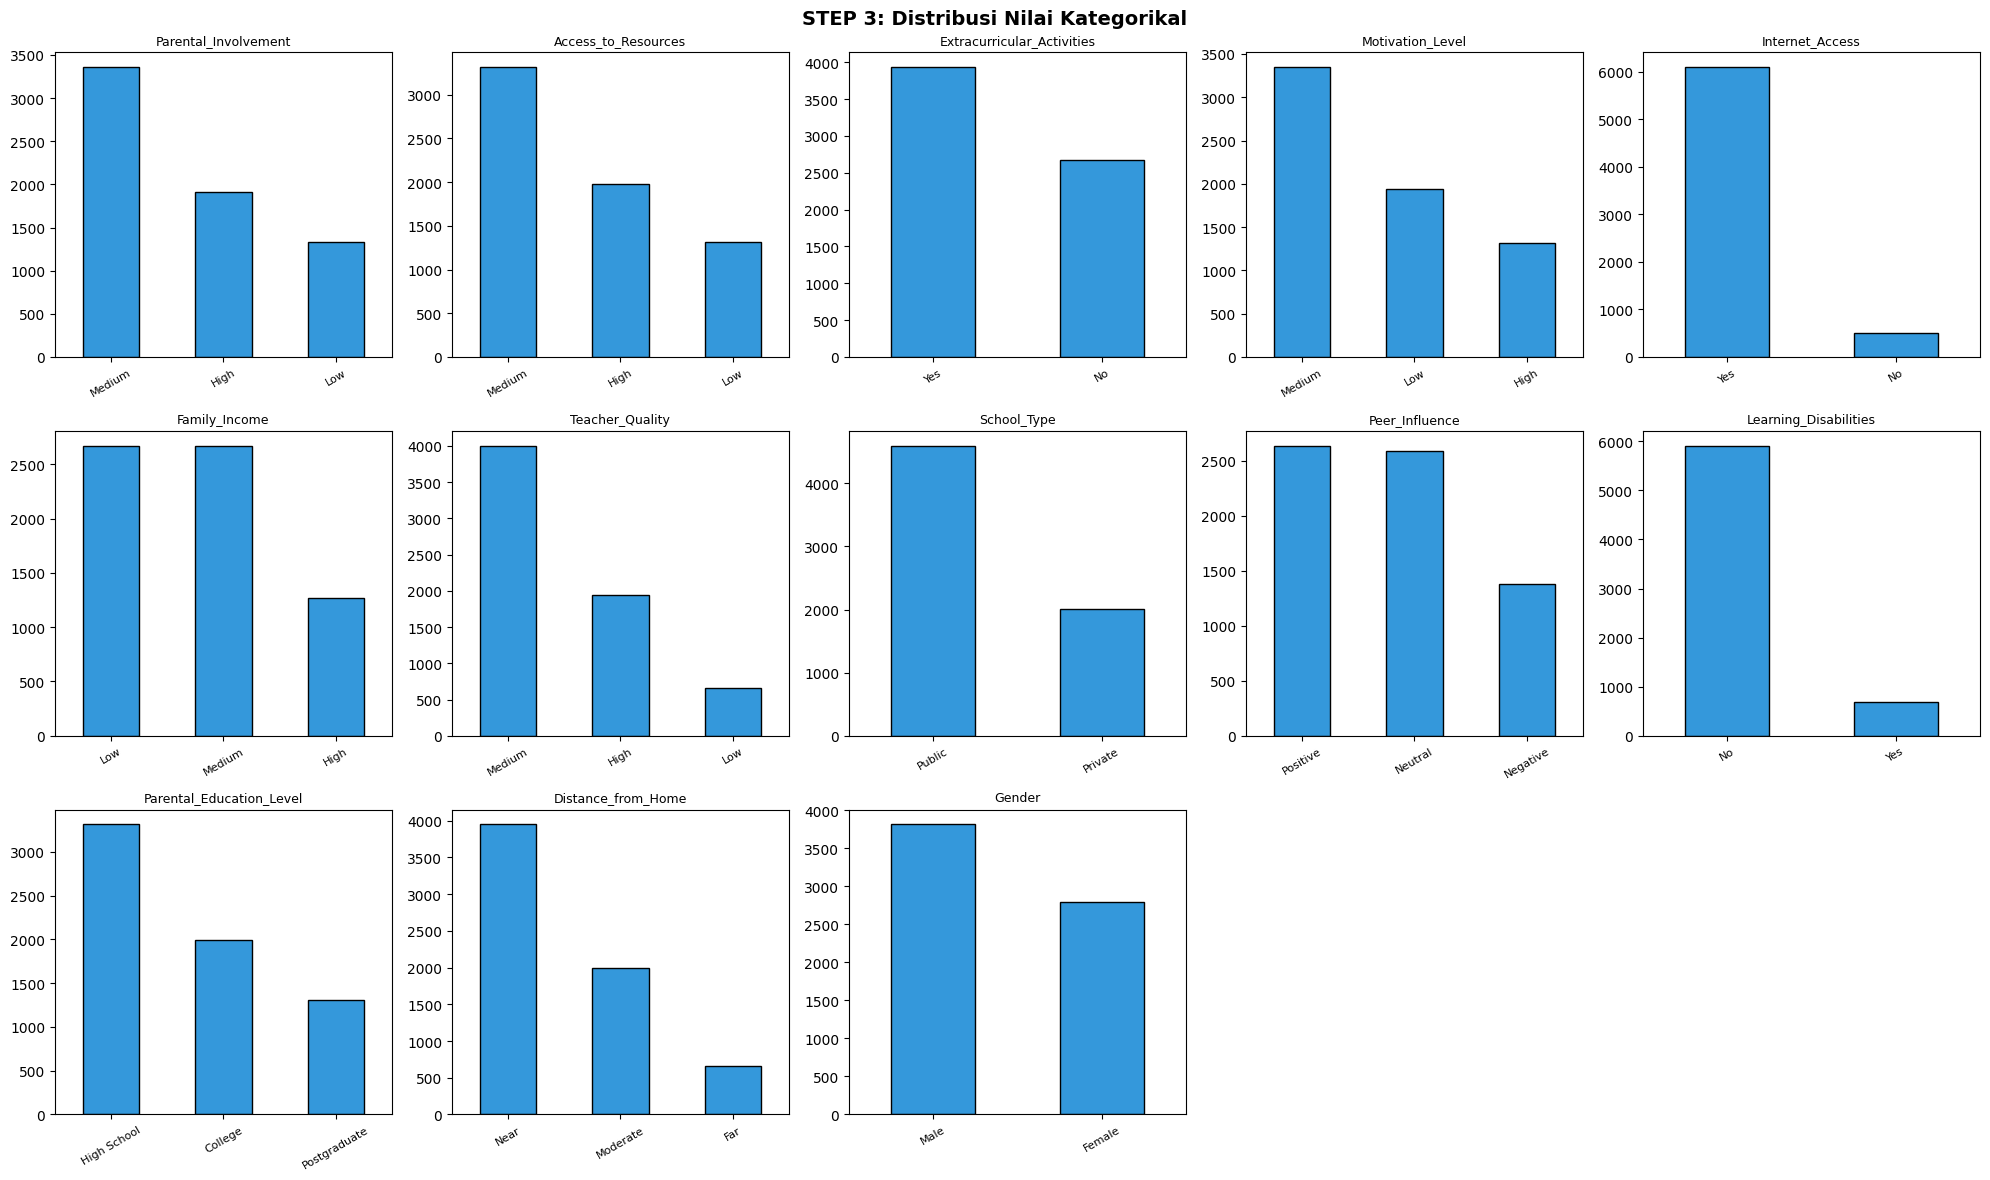

In [11]:
# Visualisasi
fig, axes = plt.subplots(3, 5, figsize=(20, 12))
fig.suptitle('STEP 3: Distribusi Nilai Kategorikal', fontsize=14, fontweight='bold')
axes = axes.flatten()
 
for i, col in enumerate(cat_cols):
    df[col].value_counts().plot(kind='bar', ax=axes[i], color='#3498DB', edgecolor='black')
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30, labelsize=8)
 
# Hide unused subplots
for j in range(len(cat_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()

# Pemeriksaan dan Penanganan Outlier

In [12]:
num_cols = ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores',
            'Tutoring_Sessions', 'Physical_Activity', 'Exam_Score']
 
outlier_summary = {}
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outlier_summary[col] = {
        'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
        'Lower Bound': lower, 'Upper Bound': upper,
        'Outlier Count': len(outliers)
    }
    print(f"  {col}: lower={lower}, upper={upper}, outlier={len(outliers)} baris")
 
outlier_df = pd.DataFrame(outlier_summary).T
print()
print(outlier_df[['Lower Bound', 'Upper Bound', 'Outlier Count']])

  Hours_Studied: lower=4.0, upper=36.0, outlier=43 baris
  Attendance: lower=40.0, upper=120.0, outlier=0 baris
  Sleep_Hours: lower=3.0, upper=11.0, outlier=0 baris
  Previous_Scores: lower=25.5, upper=125.5, outlier=0 baris
  Tutoring_Sessions: lower=-0.5, upper=3.5, outlier=430 baris
  Physical_Activity: lower=-1.0, upper=7.0, outlier=0 baris
  Exam_Score: lower=59.0, upper=75.0, outlier=104 baris

                   Lower Bound  Upper Bound  Outlier Count
Hours_Studied              4.0         36.0           43.0
Attendance                40.0        120.0            0.0
Sleep_Hours                3.0         11.0            0.0
Previous_Scores           25.5        125.5            0.0
Tutoring_Sessions         -0.5          3.5          430.0
Physical_Activity         -1.0          7.0            0.0
Exam_Score                59.0         75.0          104.0


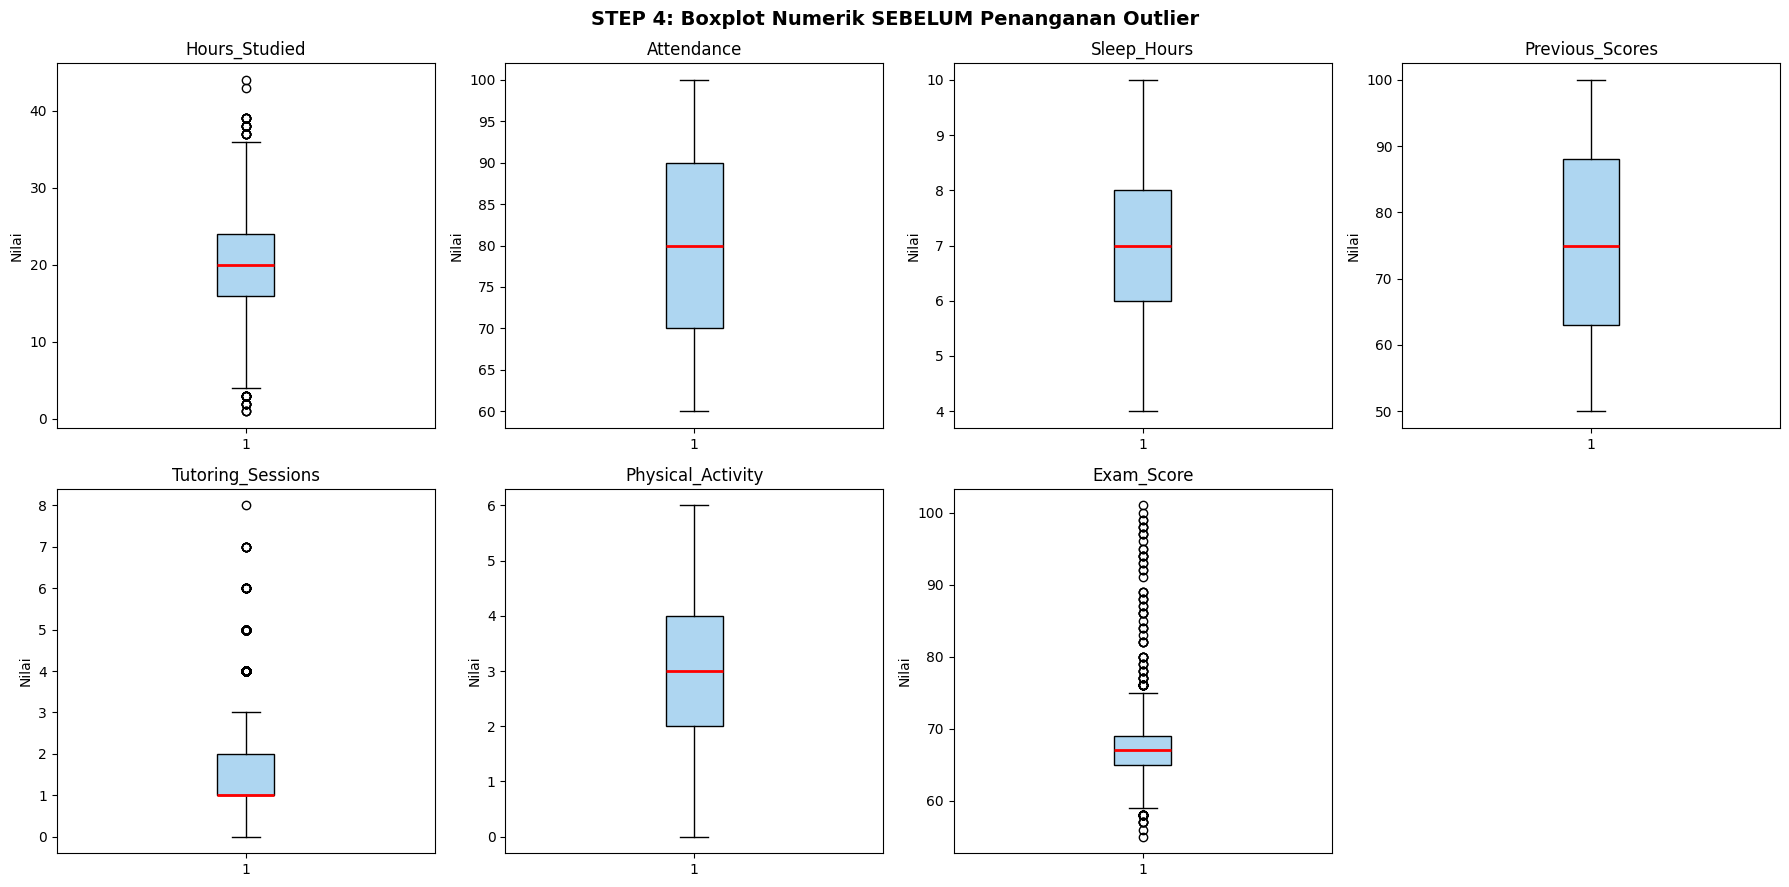

In [14]:
# Visualisasi SEBELUM penanganan outlier
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle('STEP 4: Boxplot Numerik SEBELUM Penanganan Outlier', fontsize=14, fontweight='bold')
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='#AED6F1'),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(col)
    axes[i].set_ylabel('Nilai')
axes[-1].set_visible(False)
plt.tight_layout()

In [15]:
# Penanganan Outlier
# - Hours_Studied: outlier ekstrem (nilai 1,2,3 dan 38,39,44) -> cap dengan batas IQR
# - Tutoring_Sessions: nilai 4-8, batas atas IQR hanya 3.5 -> secara logis nilai ini valid (maks 8 sesi)
#   -> TIDAK di-cap karena masih masuk akal secara domain
# - Exam_Score: nilai 55-101, beberapa sangat tinggi/rendah -> cap dengan batas IQR

cols_to_cap = ['Hours_Studied', 'Exam_Score']
for col in cols_to_cap:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    before = df[col].copy()
    df[col] = df[col].clip(lower=lower, upper=upper)
    capped = (before != df[col]).sum()
    print(f"\n  [CAPPED] {col}: {capped} nilai di-cap ke rentang [{lower:.1f}, {upper:.1f}]")
 
print("\n  [DIBIARKAN] Tutoring_Sessions: nilai 4-8 masih valid secara domain (batas max 8 sesi)")


  [CAPPED] Hours_Studied: 43 nilai di-cap ke rentang [4.0, 36.0]

  [CAPPED] Exam_Score: 104 nilai di-cap ke rentang [59.0, 75.0]

  [DIBIARKAN] Tutoring_Sessions: nilai 4-8 masih valid secara domain (batas max 8 sesi)


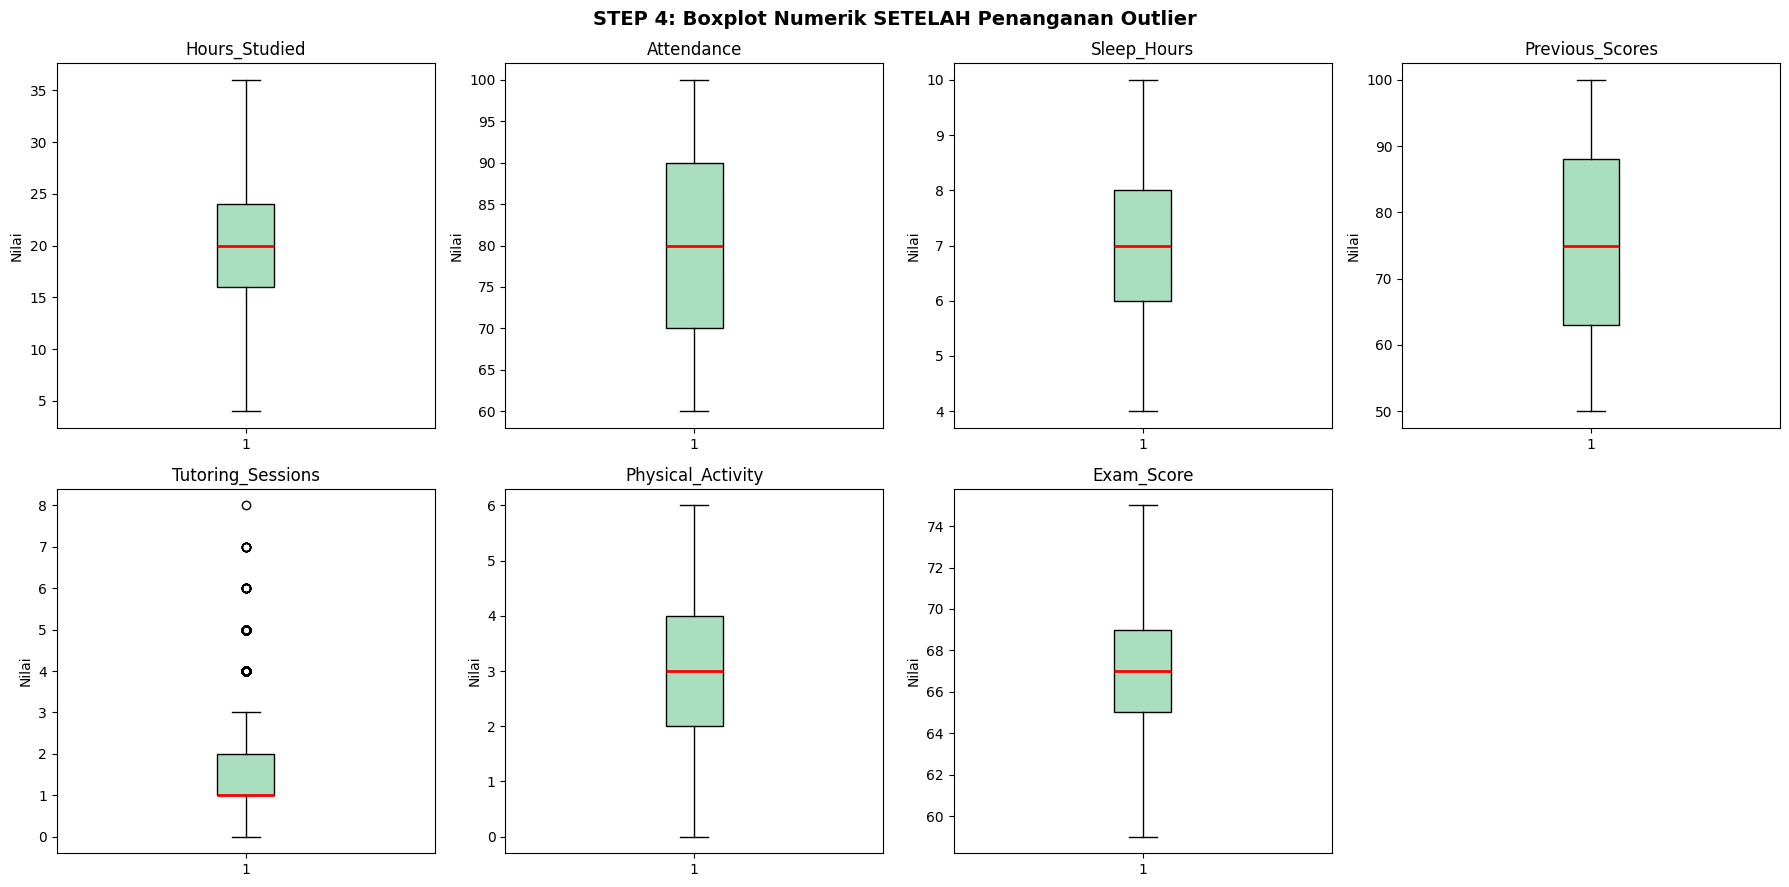

In [16]:
# Visualisasi SETELAH penanganan outlier
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle('STEP 4: Boxplot Numerik SETELAH Penanganan Outlier', fontsize=14, fontweight='bold')
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='#A9DFBF'),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(col)
    axes[i].set_ylabel('Nilai')
axes[-1].set_visible(False)
plt.tight_layout()

# Pengecekan Range/Validitas Nilai Numerik

In [17]:
valid_ranges = {
    'Attendance': (0, 100),
    'Sleep_Hours': (0, 24),
    'Previous_Scores': (0, 100),
    'Tutoring_Sessions': (0, 10),
    'Physical_Activity': (0, 7),
}
 
for col, (lo, hi) in valid_ranges.items():
    invalid = df[(df[col] < lo) | (df[col] > hi)]
    print(f"  {col} (range {lo}-{hi}): {len(invalid)} nilai tidak valid")
 
print("Semua nilai berada dalam range yang valid.")

  Attendance (range 0-100): 0 nilai tidak valid
  Sleep_Hours (range 0-24): 0 nilai tidak valid
  Previous_Scores (range 0-100): 0 nilai tidak valid
  Tutoring_Sessions (range 0-10): 0 nilai tidak valid
  Physical_Activity (range 0-7): 0 nilai tidak valid
Semua nilai berada dalam range yang valid.


# Ringkasan Statistik Akhir

In [18]:
print(f"Shape akhir: {df.shape}")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Duplikat: {df.duplicated().sum()}")
print()
print("Statistik deskriptif akhir:")
print(df[num_cols].describe().round(2))

Shape akhir: (6607, 20)
Missing values: 0
Duplikat: 0

Statistik deskriptif akhir:
       Hours_Studied  Attendance  Sleep_Hours  Previous_Scores  \
count        6607.00     6607.00      6607.00          6607.00   
mean           19.97       79.98         7.03            75.07   
std             5.95       11.55         1.47            14.40   
min             4.00       60.00         4.00            50.00   
25%            16.00       70.00         6.00            63.00   
50%            20.00       80.00         7.00            75.00   
75%            24.00       90.00         8.00            88.00   
max            36.00      100.00        10.00           100.00   

       Tutoring_Sessions  Physical_Activity  Exam_Score  
count            6607.00            6607.00     6607.00  
mean                1.49               2.97       67.13  
std                 1.23               1.03        3.37  
min                 0.00               0.00       59.00  
25%                 1.00        

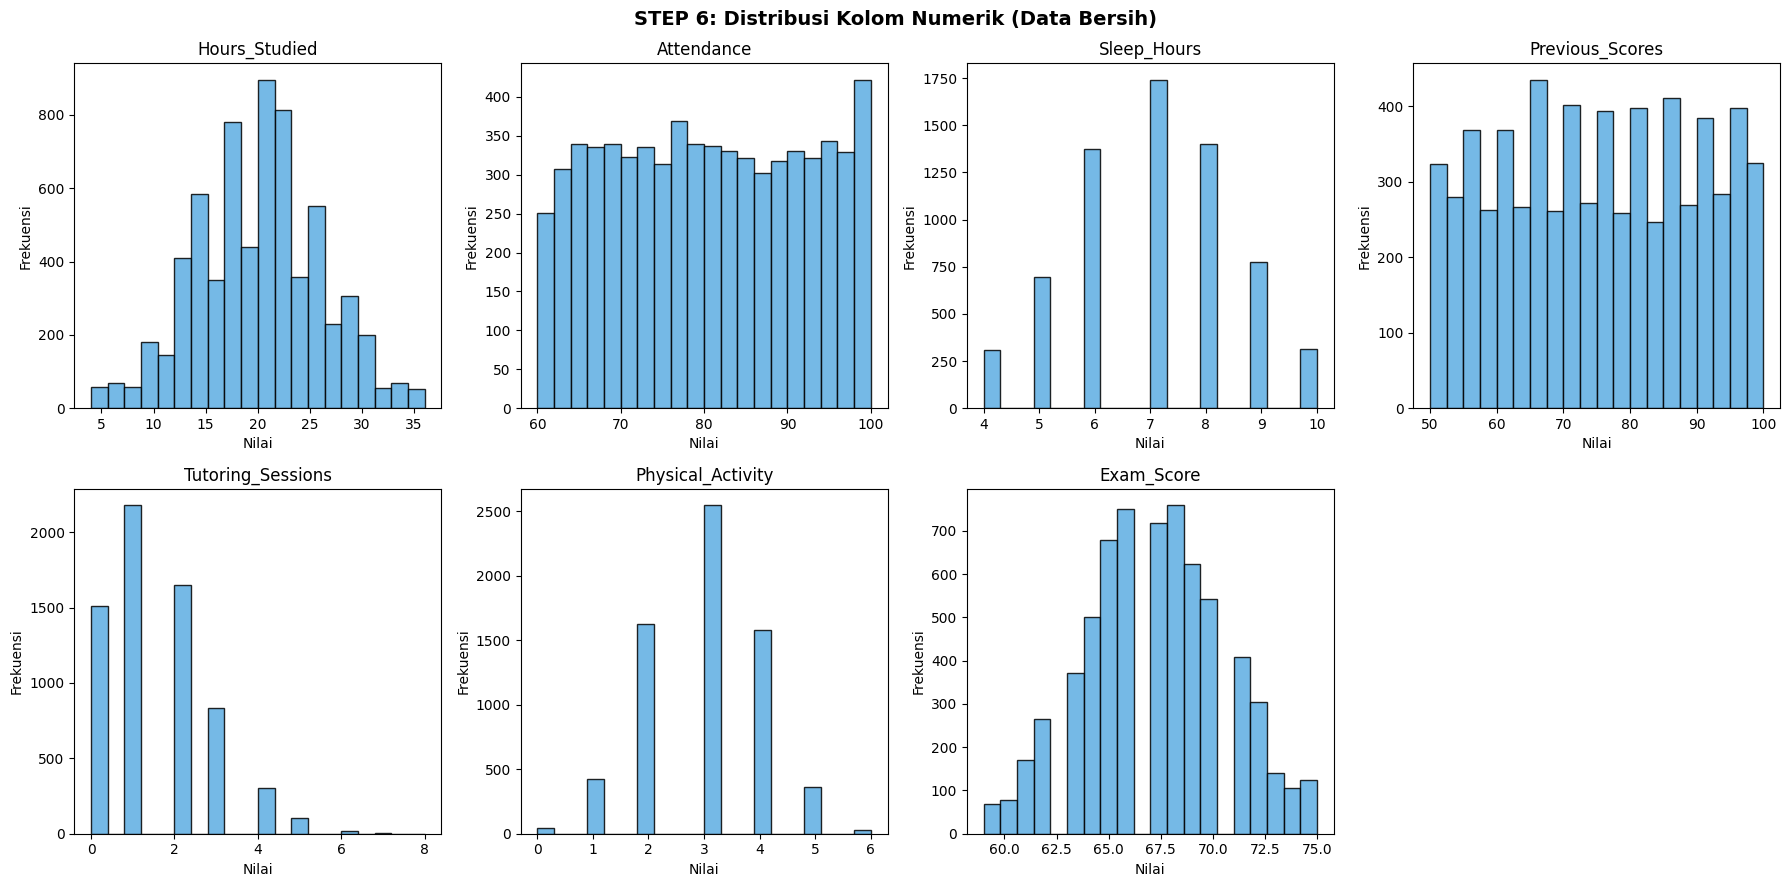

In [19]:
# Visualisasi distribusi numerik Final
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle('STEP 6: Distribusi Kolom Numerik (Data Bersih)', fontsize=14, fontweight='bold')
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=20, color='#5DADE2', edgecolor='black', alpha=0.85)
    axes[i].set_title(col)
    axes[i].set_xlabel('Nilai')
    axes[i].set_ylabel('Frekuensi')
axes[-1].set_visible(False)
plt.tight_layout()

In [25]:
output_path = "C:/Users/alish/Downloads/Lab3_Tableau/DatasetPerformaSiswa_Clean.csv"
df.to_csv(output_path, index=False)
print(f"\nData bersih berhasil disimpan ke: {output_path}")
print("PREPROCESSING SELESAI.")


Data bersih berhasil disimpan ke: C:/Users/alish/Downloads/Lab3_Tableau/DatasetPerformaSiswa_Clean.csv
PREPROCESSING SELESAI.
